In [12]:
"""
Módulo 1: Treinamento de modelos CNN
Saída: Modelos CNN treinados salvos em SAVE_DIR
"""
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import timm
import pickle
from sklearn.metrics import accuracy_score, f1_score
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from config import *
EPOCHS = 100

In [13]:
# Dataset
class LeukemiaDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Carregar imagens ALL (classe 1)
        all_dir = os.path.join(data_dir, 'all')
        if os.path.exists(all_dir):
            for img_name in os.listdir(all_dir):
                if img_name.endswith(('.jpg', '.png', '.bmp')):
                    self.images.append(os.path.join(all_dir, img_name))
                    self.labels.append(1)
        
        # Carregar imagens HEM (classe 0)
        hem_dir = os.path.join(data_dir, 'hem')
        if os.path.exists(hem_dir):
            for img_name in os.listdir(hem_dir):
                if img_name.endswith(('.jpg', '.png', '.bmp')):
                    self.images.append(os.path.join(hem_dir, img_name))
                    self.labels.append(0)
        
        print(f"Carregado: {len(self.images)} imagens - ALL: {self.labels.count(1)}, HEM: {self.labels.count(0)}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Erro ao carregar {img_path}: {e}")
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='black')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [14]:
# Transformações

def get_transforms():
    train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),  # Menos rotação
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Menos variação
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

In [15]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

In [16]:
# Modelo com Attention SE
class CNNModel(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool='',  # Removemos global_pool aqui
            drop_rate=0.3,
            drop_path_rate=0.2
        )
        
        num_features = self.backbone.num_features
        
        # Adicionar SE Attention ANTES do pooling
        self.attention = SEBlock(num_features, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # Extrair features do backbone
        features = self.backbone(x)
        # Aplicar SE attention
        features = self.attention(features)
        # Global pooling
        features = self.global_pool(features).flatten(1)
        # Classificador
        return self.classifier(features)

In [17]:

def plot_training_progress(history, model_name, save_dir):
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    
    train_color = '#FFA500'
    val_color = '#1E90FF'
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], color=train_color, 
                 linewidth=2.5, label='Train', marker='o', markersize=3, markevery=5)
    axes[0].plot(epochs, history['val_loss'], color=val_color, 
                 linewidth=2.5, label='Validation', marker='s', markersize=3, markevery=5)
    axes[0].set_xlabel('Epochs', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].set_title('(a) Loss', fontsize=12, pad=10)
    axes[0].legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].set_facecolor('#F8F8F8')
    
    # Accuracy
    axes[1].plot(epochs, history['train_acc'], color=train_color, 
                 linewidth=2.5, label='Train', marker='o', markersize=3, markevery=5)
    axes[1].plot(epochs, history['val_acc'], color=val_color, 
                 linewidth=2.5, label='Validation', marker='s', markersize=3, markevery=5)
    axes[1].set_xlabel('Epochs', fontsize=11)
    axes[1].set_ylabel('Accuracy', fontsize=11)
    axes[1].set_title('(b) Accuracy', fontsize=12, pad=10)
    axes[1].legend(loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].set_ylim([0.75, 1.0])
    axes[1].set_facecolor('#F8F8F8')
    
    # F1-Score
    axes[2].plot(epochs, history['train_f1'], color=train_color, 
                 linewidth=2.5, label='Train', marker='o', markersize=3, markevery=5)
    axes[2].plot(epochs, history['val_f1'], color=val_color, 
                 linewidth=2.5, label='Validation', marker='s', markersize=3, markevery=5)
    axes[2].set_xlabel('Epochs', fontsize=11)
    axes[2].set_ylabel('F1 Score', fontsize=11)
    axes[2].set_title('(c) F1-score', fontsize=12, pad=10)
    axes[2].legend(loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    axes[2].grid(True, alpha=0.3, linestyle='--')
    axes[2].set_ylim([0.75, 1.0])
    axes[2].set_facecolor('#F8F8F8')
    
    fig.suptitle(f'Training and Validation Curves - {model_name}', 
                 fontsize=12, y=1.02)
    
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'{model_name.replace("/", "_")}_training_curves.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"📊 Gráfico salvo em: {save_path}")
    
    plt.show()
    return fig

In [18]:
def mixup_data(x, y, alpha=0.2):
    """Aplica mixup aos dados"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calcula loss com mixup"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [19]:
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    for inputs, targets in tqdm(loader, desc='Training'):
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        if scaler is not None:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        # Backward pass
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, acc, f1

In [20]:
# Função de validação
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc='Validation'):
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, acc, f1

In [21]:
def train_single_model(model_name):
    """Treina um único modelo CNN"""
    print(f"\n{'='*50}")
    print(f"Treinando: {model_name}")
    print('='*50)
    
    # Preparar datasets
    train_transform, val_transform = get_transforms()
    train_dataset = LeukemiaDataset(TRAIN_DIR, train_transform)
    val_dataset = LeukemiaDataset(VAL_DIR, val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    
    # Criar modelo
    model = CNNModel(model_name, NUM_CLASSES).to(DEVICE)
    
    # Configurar treinamento
    # Calcular pesos das classes baseado no desbalanceamento
    def calculate_class_weights(train_dataset):
        labels = np.array(train_dataset.labels)
        class_counts = np.bincount(labels)
        total = len(labels)
        weights = total / (len(class_counts) * class_counts)
        return torch.FloatTensor(weights)

    class FocalLoss(nn.Module):
        def __init__(self, alpha=0.25, gamma=2.0, num_classes=2):
            super().__init__()
            self.alpha = alpha
            self.gamma = gamma
            self.num_classes = num_classes
            
        def forward(self, inputs, targets):
            ce_loss = F.cross_entropy(inputs, targets, reduction='none')
            pt = torch.exp(-ce_loss)
            
            # Aplicar alpha para balanceamento
            targets_one_hot = F.one_hot(targets, self.num_classes).float()
            alpha_t = self.alpha * targets_one_hot[:, 1] + (1 - self.alpha) * targets_one_hot[:, 0]
            
            focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
            return focal_loss.mean()


    # Configurar treinamento
    class_weights = calculate_class_weights(train_dataset).to(DEVICE)
    criterion = FocalLoss(alpha=0.25, gamma=2.0, num_classes=NUM_CLASSES)

    # Configurar otimizador conforme artigo
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=1e-4,  # Learning rate do artigo
        weight_decay=1e-5,
        betas=(0.9, 0.999)
    )

    # OneCycleLR como no artigo
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        epochs=50,  # Máximo de 50 epochs como no artigo
        steps_per_epoch=len(train_loader),
        anneal_strategy='cos'
    )

    # Early stopping mais rigoroso
    class EarlyStopping:
        def __init__(self, patience=10, min_delta=0.001):
            self.patience = patience
            self.min_delta = min_delta
            self.counter = 0
            self.best_score = None
            self.early_stop = False
            
        def __call__(self, val_score):
            if self.best_score is None:
                self.best_score = val_score
            elif val_score < self.best_score + self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = val_score
                self.counter = 0
            return self.early_stop



    scaler = GradScaler() if DEVICE.type == 'cuda' else None
    
    # Treinar
    best_f1 = 0
    best_gap = float('inf')  # Menor diferença entre train e val
    early_stopping = EarlyStopping(patience=50, min_delta=0.002)
    history = {
    'train_loss': [], 'val_loss': [], 
    'train_acc': [],  'val_acc': [],    
    'train_f1': [], 'val_f1': []
    }
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        # Treinar
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        
        # Validar
        val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, DEVICE)
        
        # Atualizar scheduler
        scheduler.step(val_loss)
        
        # Registrar métricas
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
        

        gap = abs(train_f1 - val_f1)

        # Salvar melhor modelo
        if val_f1 > best_f1 or (val_f1 == best_f1 and gap < best_gap):
            best_f1 = val_f1
            best_gap = gap
            model_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "_")}_best.pt')

            # Certificar-se de que estamos salvando corretamente
            checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'best_f1': best_f1,
            'val_f1': val_f1,
            'train_f1': train_f1,
            'gap': gap,
            'val_loss': val_loss
            }

            # Verificações antes de salvar
            assert isinstance(checkpoint, dict), "Checkpoint deve ser dict"
            assert 'model_state_dict' in checkpoint, "model_state_dict ausente"
            assert isinstance(checkpoint['model_state_dict'], dict), "state_dict deve ser dict"

            # Criar diretório se não existir
            os.makedirs(SAVE_DIR, exist_ok=True)
 
            torch.save(checkpoint, model_path)
            print(f"✅ Modelo salvo - F1: {best_f1:.4f}, Gap: {gap:.4f}")
        
        # Early stopping
        if early_stopping(val_f1):
            print("Early stopping triggered!")
            break
    
    # Salvar histórico
    plot_training_progress(history, model_name, SAVE_DIR)
    history_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "_")}_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)
    
    return best_f1

Iniciando treinamento de modelos CNN...

Treinando: tf_efficientnetv2_b3
Carregado: 11102 imagens - ALL: 5335, HEM: 5767
Carregado: 1172 imagens - ALL: 571, HEM: 601

Epoch 1/100


Validation: 100%|██████████| 147/147 [00:09<00:00, 15.08it/s]


Train Loss: 0.0550 | Train F1: 0.7844
Val Loss: 0.0331 | Val F1: 0.8552
✅ Modelo salvo - F1: 0.8552, Gap: 0.0708

Epoch 2/100


Validation: 100%|██████████| 147/147 [00:08<00:00, 17.28it/s]


Train Loss: 0.0417 | Train F1: 0.8467
Val Loss: 0.0251 | Val F1: 0.9119
✅ Modelo salvo - F1: 0.9119, Gap: 0.0652

Epoch 3/100


...

Train Loss: 0.0035 | Train F1: 0.9908
Val Loss: 0.0185 | Val F1: 0.9581

Epoch 64/100


Validation: 100%|██████████| 147/147 [00:08<00:00, 18.13it/s]


Train Loss: 0.0031 | Train F1: 0.9925
Val Loss: 0.0207 | Val F1: 0.9522

Epoch 65/100


Validation: 100%|██████████| 147/147 [00:08<00:00, 17.82it/s]


Train Loss: 0.0033 | Train F1: 0.9909
Val Loss: 0.0127 | Val F1: 0.9478
Early stopping triggered!
📊 Gráfico salvo em: models/modular/tf_efficientnetv2_b3_training_curves.png


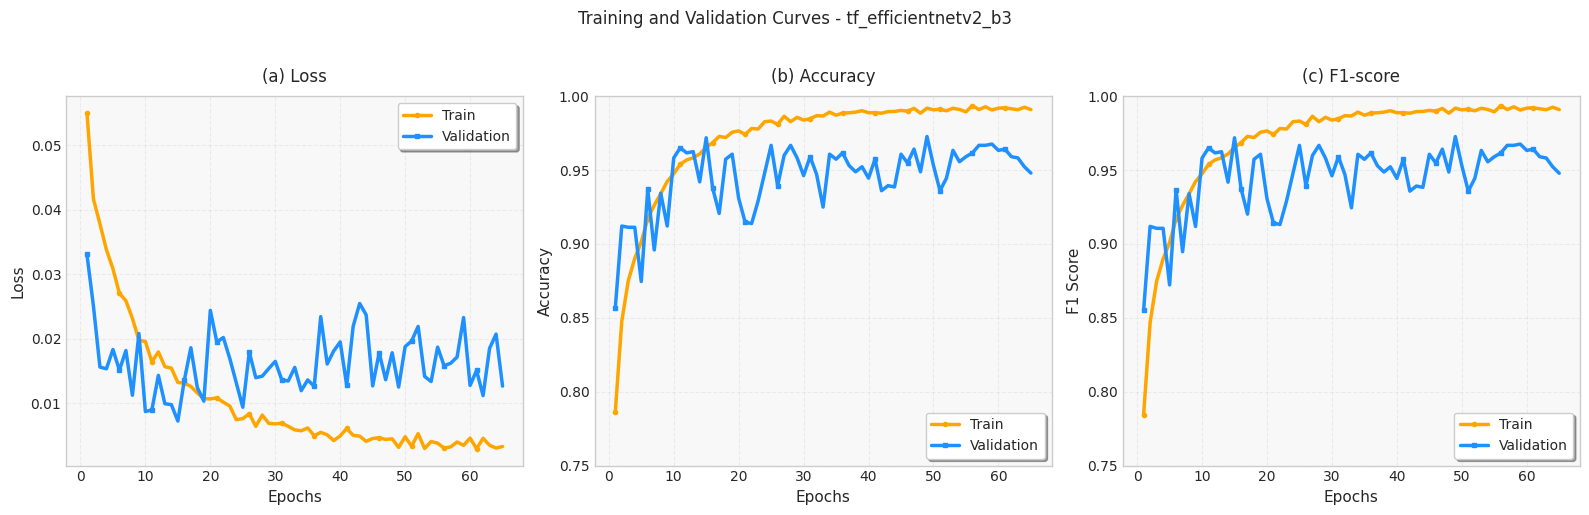


RESULTADOS FINAIS:
tf_efficientnetv2_b3: F1-Score = 0.9727


In [22]:
def main():
    print("Iniciando treinamento de modelos CNN...")
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    
    results = {}
    for model_name in CNN_MODELS:
        try:
            best_f1 = train_single_model(model_name)
            results[model_name] = best_f1
            
            # Limpar memória
            torch.cuda.empty_cache()
            
        except Exception as e:
            print(f"Erro ao treinar {model_name}: {e}")
            results[model_name] = 0
    
    print("\n" + "="*50)
    print("RESULTADOS FINAIS:")
    for name, f1 in results.items():
        print(f"{name}: F1-Score = {f1:.4f}")
    
    # Salvar resumo
    with open(os.path.join(SAVE_DIR, 'cnn_training_results.pkl'), 'wb') as f:
        pickle.dump(results, f)

if __name__ == "__main__":
    main()